In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# 1. Load the dataset
df = pd.read_csv('data/listings.csv')

# 2. Data Cleaning
# Remove '$' and ',' from the 'price' column and convert it to float
df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(float)

# 3. Feature Selection (Simple Model)
# We select only numerical columns for now to train our first model
# 'accommodates': Number of people the place accommodates
# 'bedrooms': Number of bedrooms
# 'price': The target variable to predict
ml_data = df[['accommodates', 'bedrooms', 'price']].dropna()

# Display the first 5 rows to check data
ml_data.head()

,accommodates,bedrooms,price
0,4,1.0,105.0
1,7,4.0,180.0
2,1,0.0,70.0
3,4,1.0,90.0
4,2,0.0,25.0


In [8]:
# Define Features (X) and Target (y)
X = ml_data[['accommodates', 'bedrooms']]  # Questions (Inputs)
y = ml_data['price']                        # Answers (Output)

# Split the data into Training and Testing sets
# test_size=0.2: Keep 20% of the data for testing (the exam)
# random_state=42: Ensures the split is the same every time we run this code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the shapes of the split datasets
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (7052, 2)
Test set size: (1764, 2)


In [9]:
# 1. Initialize the Model (Architecture Selection)
# We choose Linear Regression because we want to predict a continuous value (Price).
model = LinearRegression()

# 2. Train the Model (Fitting)
# The model learns the relationship between Features (X_train) and Target (y_train).
# It calculates the best coefficients (weights) to minimize error.
model.fit(X_train, y_train)

print("Training completed successfully!")

# 3. Inspect the Learned Parameters (Optional but Recommended)
# Let's see how much price the model assigns to each feature based on math.
print(f"Base Price (Intercept): {model.intercept_:.2f} €")  # Starting price (if inputs were 0)
print(f"Price per Accommodate: {model.coef_[0]:.2f} €")     # Value of +1 person capacity
print(f"Price per Bedroom: {model.coef_[1]:.2f} €")         # Value of +1 bedroom

Training completed successfully!
Base Price (Intercept): 23.37 €
Price per Accommodate: 33.16 €
Price per Bedroom: 18.62 €


In [10]:
# 6. Make Predictions (The Exam)
# We give the unseen test questions (X_test) to the model.
# The model uses its learned formula to guess the prices (y_pred).
y_pred = model.predict(X_test)

# 7. Evaluate the Model (The Scorecard)
# We compare the Guessed Prices (y_pred) with the Actual Prices (y_test).
# MAE (Mean Absolute Error): On average, how many Euros are we off?
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} €")

# Let's compare the first 5 predictions side-by-side
results = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})
print("\n--- First 5 Comparisons ---")
print(results.head())

Mean Absolute Error (MAE): 64.95 €

--- First 5 Comparisons ---
       Actual Price  Predicted Price
6611           70.0       108.320116
10860         380.0       444.041000
7667           55.0       108.320116
12628         205.0       174.647850
13277          55.0       174.647850


In [11]:
# --- STEP 2: Improving the Model (Adding Room Type) ---

# 1. Select Features
# We now include 'room_type' because the type of room significantly affects the price.
# dropna() removes rows with missing values to prevent errors.
model_data_v2 = df[['accommodates', 'bedrooms', 'room_type', 'price']].dropna()

# 2. One-Hot Encoding (The Magic Trick ✨)
# Computers cannot understand text like "Entire home". 
# We convert these text categories into mathematical numbers (0 and 1).
# drop_first=True avoids redundancy (dummy variable trap).
model_data_v2 = pd.get_dummies(model_data_v2, columns=['room_type'], drop_first=True)

# Let's check how the data looks now
print("New Data Structure (First 5 rows):")
print(model_data_v2.head())

# --- TRAINING THE MODEL ---

# Define X (Features/Inputs) and y (Target/Price)
X_v2 = model_data_v2.drop('price', axis=1) # Everything except price is an input
y_v2 = model_data_v2['price']              # Price is what we want to predict

# Split the data: 80% for Training, 20% for Testing
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

# Initialize and Train the Linear Regression Model
model_v2 = LinearRegression()
model_v2.fit(X_train_v2, y_train_v2)

# Make Predictions on the Test Set
y_pred_v2 = model_v2.predict(X_test_v2)

# Evaluate the Model
# We calculate the Mean Absolute Error (MAE) to see how much we improved.
mae_v2 = mean_absolute_error(y_test_v2, y_pred_v2)

print(f"\nPrevious MAE: 64.95 €")
print(f"New MAE:      {mae_v2:.2f} €")

New Data Structure (First 5 rows):
   accommodates  bedrooms  price  room_type_Hotel room  \
0             4       1.0  105.0                 False   
1             7       4.0  180.0                 False   
2             1       0.0   70.0                 False   
3             4       1.0   90.0                 False   
4             2       0.0   25.0                 False   

   room_type_Private room  room_type_Shared room  
0                   False                  False  
1                   False                  False  
2                   False                  False  
3                   False                  False  
4                   False                  False  

Previous MAE: 64.95 €
New MAE:      63.43 €


In [14]:
# --- STEP 3: Adding the "Golden Rule" (Location) - CORRECTED ---

# 1. Select Features
# We use 'neighbourhood_group_cleansed' which contains the main districts (Mitte, Pankow etc.)
columns_to_use = ['accommodates', 'bedrooms', 'room_type', 'neighbourhood_group_cleansed', 'price']
model_data_v3 = df[columns_to_use].dropna()

# 2. One-Hot Encoding
# Converting "Mitte", "Private room" etc. into numbers.
model_data_v3 = pd.get_dummies(model_data_v3, columns=['room_type', 'neighbourhood_group_cleansed'], drop_first=True)

# Let's verify the new columns
print("New Location Columns Added:")
print(model_data_v3.columns.tolist())

# --- TRAINING THE MODEL v3 ---

X_v3 = model_data_v3.drop('price', axis=1)
y_v3 = model_data_v3['price']

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(X_v3, y_v3, test_size=0.2, random_state=42)

model_v3 = LinearRegression()
model_v3.fit(X_train_v3, y_train_v3)

y_pred_v3 = model_v3.predict(X_test_v3)
mae_v3 = mean_absolute_error(y_test_v3, y_pred_v3)

print(f"\nMAE (Base Model):      64.95 €")
print(f"MAE (with Room Type):  63.43 €")
print(f"MAE (with Location):   {mae_v3:.2f} €")

New Location Columns Added:
['accommodates', 'bedrooms', 'price', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_group_cleansed_Friedrichshain-Kreuzberg', 'neighbourhood_group_cleansed_Lichtenberg', 'neighbourhood_group_cleansed_Marzahn - Hellersdorf', 'neighbourhood_group_cleansed_Mitte', 'neighbourhood_group_cleansed_Neukölln', 'neighbourhood_group_cleansed_Pankow', 'neighbourhood_group_cleansed_Reinickendorf', 'neighbourhood_group_cleansed_Spandau', 'neighbourhood_group_cleansed_Steglitz - Zehlendorf', 'neighbourhood_group_cleansed_Tempelhof - Schöneberg', 'neighbourhood_group_cleansed_Treptow - Köpenick']

MAE (Base Model):      64.95 €
MAE (with Room Type):  63.43 €
MAE (with Location):   62.25 €


In [15]:
# --- STEP 4: Changing the Algorithm (Random Forest)  ---
from sklearn.ensemble import RandomForestRegressor

# We use the EXACT same data (X_train_v3, y_train_v3)
# But we change the algorithm from "Linear" to "Forest"

print("Training Random Forest Model... (This might take a few seconds)")

# 1. Initialize the Random Forest Model
# n_estimators=100: We create 100 decision trees (a council of 100 experts)
# random_state=42: Ensures we get the same result every time
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the Model
rf_model.fit(X_train_v3, y_train_v3)

# 3. Predict & Evaluate
y_pred_rf = rf_model.predict(X_test_v3)
mae_rf = mean_absolute_error(y_test_v3, y_pred_rf)

print(f"\n--- SCOREBOARD ---")
print(f"Linear Regression MAE: {mae_v3:.2f} €")
print(f"Random Forest MAE:     {mae_rf:.2f} €") 
print(f"Improvement:           {mae_v3 - mae_rf:.2f} € better!")

Training Random Forest Model... (This might take a few seconds)

--- SCOREBOARD ---
Linear Regression MAE: 62.25 €
Random Forest MAE:     65.48 €
Improvement:           -3.22 € better!


In [16]:
print("--- Modele Giren Özelliklerin Tam Listesi ---")
features = X_train_v3.columns.tolist()
for feature in features:
    print(f"- {feature}")

print(f"\nToplam Özellik Sayısı: {len(features)}")

--- Modele Giren Özelliklerin Tam Listesi ---
- accommodates
- bedrooms
- room_type_Hotel room
- room_type_Private room
- room_type_Shared room
- neighbourhood_group_cleansed_Friedrichshain-Kreuzberg
- neighbourhood_group_cleansed_Lichtenberg
- neighbourhood_group_cleansed_Marzahn - Hellersdorf
- neighbourhood_group_cleansed_Mitte
- neighbourhood_group_cleansed_Neukölln
- neighbourhood_group_cleansed_Pankow
- neighbourhood_group_cleansed_Reinickendorf
- neighbourhood_group_cleansed_Spandau
- neighbourhood_group_cleansed_Steglitz - Zehlendorf
- neighbourhood_group_cleansed_Tempelhof - Schöneberg
- neighbourhood_group_cleansed_Treptow - Köpenick

Toplam Özellik Sayısı: 16


C:\Users\aycay\AppData\Local\Temp\ipykernel_2136\2172692567.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


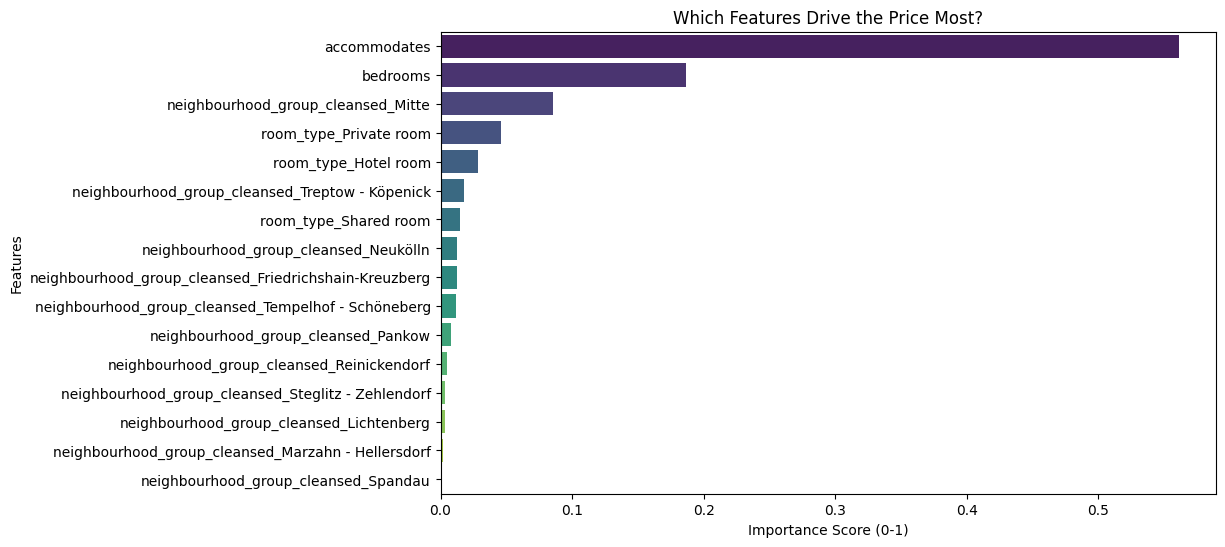

Top 5 Most Important Factors:
                              Feature  Importance
0                        accommodates    0.561000
1                            bedrooms    0.186564
8  neighbourhood_group_cleansed_Mitte    0.085479
3              room_type_Private room    0.046271
2                room_type_Hotel room    0.028667


In [18]:
# --- STEP 5: Feature Importance ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract Feature Importance
# We ask the Random Forest model: "Which features were most useful for predicting price?"
feature_importance = pd.DataFrame({
    'Feature': X_train_v3.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False) # Sort from most important to least

# 2. Visualize the Data
# A bar chart to easily see the winners and losers.
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')

# Add titles and labels for clarity
plt.title('Which Features Drive the Price Most?')
plt.xlabel('Importance Score (0-1)')
plt.ylabel('Features')
plt.show()

# 3. Print the Top 5 Factors numerically
print("Top 5 Most Important Factors:")
print(feature_importance.head(5))

In [20]:
# --- STEP 6: Handling Outliers (Data Surgery 🔪) ---

# 1. Filter the Data
# We remove listings more expensive than 300 Euros.
# This eliminates the "Ultra Luxury" noise that confuses the model.
df_filtered = df[df['price'] < 300].copy()

print(f"Original Listings: {len(df)}")
print(f"Cleaned Listings:  {len(df_filtered)}")
print(f"Dropped:           {len(df) - len(df_filtered)} rows (Luxury/Outliers)")

# 2. Prepare the Clean Data
# Select features
columns_to_use = ['accommodates', 'bedrooms', 'room_type', 'neighbourhood_group_cleansed', 'price']
model_data_clean = df_filtered[columns_to_use].dropna()

# One-Hot Encoding
model_data_clean = pd.get_dummies(model_data_clean, columns=['room_type', 'neighbourhood_group_cleansed'], drop_first=True)

# 3. Split Train/Test
X_clean = model_data_clean.drop('price', axis=1)
y_clean = model_data_clean['price']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# 4. Train Random Forest (On Clean Data)
print("\nTraining Random Forest on Clean Data... ")
rf_model_clean = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_clean.fit(X_train_c, y_train_c)

# 5. Evaluate
y_pred_c = rf_model_clean.predict(X_test_c)
mae_c = mean_absolute_error(y_test_c, y_pred_c)

print(f"\n--- FINAL RESULT ---")
print(f"Old Error (with outliers): ~65.00 €")
print(f"New Error (CLEAN DATA):    {mae_c:.2f} €")

Original Listings: 13759
Cleaned Listings:  8038
Dropped:           5721 rows (Luxury/Outliers)

Training Random Forest on Clean Data... 

--- FINAL RESULT ---
Old Error (with outliers): ~65.00 €
New Error (CLEAN DATA):    40.27 €


In [24]:
# --- GRAND FINALE: Let's Predict YOUR Future Home  ---

import pandas as pd

# 1. Senaryoyu Oluştur (Berlin Hayalin)
my_dream_home = pd.DataFrame({
    'accommodates': [1],   # 1 Kişilik
    'bedrooms': [1],       # 1 Yatak odası
    'room_type_Private room': [1], # Özel oda (Evet=1)
    'room_type_Shared room': [0],  # Paylaşımlı değil
    'room_type_Hotel room': [0],   # Otel değil
    'neighbourhood_group_cleansed_Mitte': [1], # Mitte'de olsun (Evet=1)
    # Diğer ilçeler otomatik 0 olacak, o yüzden onları tek tek yazmaya gerek yok,
    # ama model hata vermesin diye boş bir şablon doldurmamız lazım.
})

# Modelin beklediği tüm sütunları oluştur ve 0 ile doldur
missing_cols = set(X_train_c.columns) - set(my_dream_home.columns)
for c in missing_cols:
    my_dream_home[c] = 0

# Sütun sırasını eğitimdekiyle aynı yap (Karışıklık olmasın)
my_dream_home = my_dream_home[X_train_c.columns]

# 2. Tahmin Et!
predicted_price = rf_model_clean.predict(my_dream_home)

print(f"---  GELECEK TAHMİNİ ---")
print(f"Senin Berlin (Mitte) evinin tahmini gecelik fiyatı:")
print(f" {predicted_price[0]:.2f} Euro")

---  GELECEK TAHMİNİ ---
Senin Berlin (Mitte) evinin tahmini gecelik fiyatı:
 72.84 Euro
